# Simulação térmica por diferenças/volumes finitos — Gêmeo Digital da GPU

**Projeto:** Gêmeo Digital Térmico de Hardware Computacional  
**Aplicação:** placa GPU de inferência de IA em operação contínua  
**Referência térmica:** NVIDIA L4 — potência de projeto de 72 W  
**Material do dissipador:** Alumínio 6061  
**Método:** equação do calor 2D em regime permanente, discretização por volumes finitos (conservativa) e fronteira convectiva.

## Objetivo

Resolver numericamente a distribuição de temperatura no dissipador do CAD integrado ao projeto e verificar a temperatura de equilíbrio para diferentes coeficientes de convecção `h`.

O modelo segue os parâmetros definidos no relatório:

- base: **170 × 70 × 5 mm**;
- 12 aletas longitudinais;
- aletas: **170 × 2 × 25 mm**;
- altura total: **30 mm**;
- potência térmica: **72 W**;
- ambiente nominal: **25 °C**;
- limite de projeto: **80 °C**;
- condutividade térmica adotada para Al 6061: **160 W/m·K**.

> **Nota sobre o CoolProp:** CoolProp é utilizado para propriedades do fluido (ar). As propriedades do sólido Al 6061 são parâmetros do próprio projeto, pois CoolProp não é uma biblioteca geral de propriedades de sólidos metálicos. Se o ambiente já possuir CoolProp, ele será utilizado; caso contrário, o notebook usa um fallback documentado para manter a execução sem instalação.

> **Versão 2 (revisada).** Esta versão corrige o solucionador: a versão anterior (SOR com 12 000 iterações) não convergia até a tolerância e apresentava erro de balanço de energia de ≈ 39 %. A discretização agora é conservativa (balanço de energia fechado em 72 W) e resolvida por solução direta esparsa (`scipy`, disponível no Google Colab).

In [ ]:
# Bibliotecas — NumPy, SciPy e Matplotlib.
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from pathlib import Path

# CoolProp é opcional no ambiente de execução.
# Se estiver disponível, será usado para propriedades do ar.
try:
    from CoolProp.CoolProp import PropsSI
    COOLPROP_OK = True
except ImportError:
    COOLPROP_OK = False

print("CoolProp disponível:", COOLPROP_OK)
print("NumPy:", np.__version__)

CoolProp disponível: False
NumPy: 2.4.4


## 1. Parâmetros geométricos e térmicos

Os valores abaixo são os mesmos utilizados na especificação CAD integrada (Anexo B do relatório). As aletas são distribuídas uniformemente, com **margem lateral de 3 mm** em cada borda da base. O espaçamento livre entre aletas é calculado automaticamente:

$$
g = \frac{W-2m-Nt_f}{N-1}
$$

onde `W` é a largura da base, `m` a margem lateral, `N` o número de aletas e `t_f` a espessura de cada aleta. Com os valores do projeto, `g = (70 − 6 − 24)/11 ≈ 3,636 mm`.

**Correspondência de eixos:** neste notebook `x` é a largura (eixo Y do CAD), `y` é a altura (eixo Z do CAD) e a profundidade de 170 mm (eixo X do CAD) é a direção extrudada.

In [ ]:
# =========================
# PARÂMETROS DO GÊMEO DIGITAL
# =========================

# Geometria [m]
W = 70e-3          # largura da base
L = 170e-3         # profundidade/comprimento das aletas
t_base = 5e-3      # espessura da base
h_fin = 25e-3      # altura das aletas
N_fin = 12         # número de aletas
t_fin = 2e-3       # espessura de cada aleta
margem = 3e-3      # margem lateral entre a borda da base e a primeira/última aleta

H_total = t_base + h_fin
gap = (W - 2*margem - N_fin*t_fin) / (N_fin - 1)

# Condições térmicas
P = 72.0           # W
T_amb_C = 25.0     # °C
T_lim_C = 80.0     # °C

# Material — Al 6061, conforme o relatório
k_al = 160.0       # W/(m.K)
rho_al = 2700.0    # kg/m³
cp_al = 896.0      # J/(kg.K), usado apenas se for feita análise transiente

print(f"Dimensão externa: {W*1e3:.1f} x {L*1e3:.1f} x {H_total*1e3:.1f} mm")
print(f"Margem lateral: {margem*1e3:.1f} mm | espaçamento entre aletas: {gap*1e3:.3f} mm")
print(f"Potência térmica: {P:.1f} W")
print(f"Temperatura ambiente: {T_amb_C:.1f} °C")
print(f"Limite de projeto: {T_lim_C:.1f} °C")

Dimensão externa: 70.0 x 170.0 x 30.0 mm
Margem lateral: 3.0 mm | espaçamento entre aletas: 3.636 mm
Potência térmica: 72.0 W
Temperatura ambiente: 25.0 °C
Limite de projeto: 80.0 °C


## 2. Propriedades do ar com CoolProp

Para uma simulação com convecção, o coeficiente `h` é fornecido como condição de contorno. O CoolProp é usado para obter propriedades do ar na temperatura ambiente de referência (25 °C).

A densidade e a viscosidade não entram diretamente na equação estacionária quando `h` é imposto, mas são registradas para tornar o modelo reproduzível e permitir uma futura correlação de convecção.

Se CoolProp não estiver disponível no ambiente, são usados valores de referência próximos às condições ambientes, evitando que a execução seja interrompida.

In [ ]:
# =========================
# PROPRIEDADES DO AR
# =========================

Tref_K = T_amb_C + 273.15   # temperatura de referência (ambiente)

if COOLPROP_OK:
    rho_air = PropsSI("D", "T", Tref_K, "P", 101325, "Air")
    mu_air = PropsSI("V", "T", Tref_K, "P", 101325, "Air")
    k_air = PropsSI("L", "T", Tref_K, "P", 101325, "Air")
    cp_air = PropsSI("C", "T", Tref_K, "P", 101325, "Air")
    source_air = "CoolProp"
else:
    # Fallback para manter o notebook executável sem instalação.
    rho_air = 1.184
    mu_air = 1.849e-5
    k_air = 0.0255
    cp_air = 1007.0
    source_air = "fallback de referência"

print(f"Fonte das propriedades: {source_air}")
print(f"rho_ar = {rho_air:.4f} kg/m³")
print(f"mu_ar  = {mu_air:.4e} Pa.s")
print(f"k_ar   = {k_air:.5f} W/(m.K)")
print(f"cp_ar  = {cp_air:.1f} J/(kg.K)")

Fonte das propriedades: fallback de referência
rho_ar = 1.1840 kg/m³
mu_ar  = 1.8490e-05 Pa.s
k_ar   = 0.02550 W/(m.K)
cp_ar  = 1007.0 J/(kg.K)


## 3. Domínio 2D do dissipador

O modelo usa uma seção transversal `x-y` da base e das 12 aletas. A profundidade de 170 mm entra no balanço energético para converter o problema 2D em uma representação do componente extrudado.

A região sólida é definida por:

- base: `0 ≤ y ≤ 5 mm`;
- aletas: `5 mm < y ≤ 30 mm`, nas 12 posições.

A malha é **não uniforme e alinhada à geometria**: as arestas das células coincidem exatamente com as faces das aletas e da base, de modo que as dimensões do CAD são reproduzidas sem arredondamento.

A face inferior da base representa o contato com a GPU/TIM e, portanto, **não é tratada como uma superfície convectiva**. O calor de 72 W é introduzido na base. As demais superfícies expostas ao ar recebem condição de convecção. As faces de extremidade (planos de 170 mm de profundidade) são desprezadas (≈ 1,6 % da área convectiva).

### Equação governante

Em regime permanente:

$$
\nabla\cdot(k\nabla T)+\dot q=0
$$

Na superfície exposta:

$$
-k\frac{\partial T}{\partial n}=h(T-T_\infty)
$$

Para o modelo discreto, a condição convectiva é incorporada à equação de cada célula de superfície.

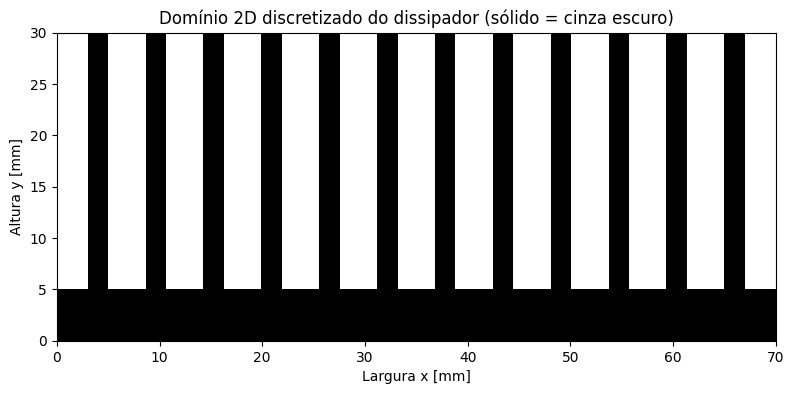

Malha: 144 x 60 células (3840 células sólidas)
Aresta mínima: dx = 0.455 mm | dy = 0.500 mm


In [ ]:
def build_mesh(refine=1):
    # Malha não uniforme alinhada à geometria. refine multiplica o número de células.
    nf, ng, nb, nh = 4*refine, 8*refine, 10*refine, 50*refine

    # Segmentos em x: margem | aleta | folga | ... | aleta | margem
    segs = [("gap", margem, max(1, ng//2))]
    for i in range(N_fin):
        segs.append(("fin", t_fin, nf))
        if i < N_fin - 1:
            segs.append(("gap", gap, ng))
    segs.append(("gap", margem, max(1, ng//2)))

    xe, is_fin = [0.0], []
    for kind, length, n in segs:
        xe.extend(xe[-1] + length*np.arange(1, n+1)/n)
        is_fin.extend([kind == "fin"]*n)
    xe = np.array(xe)
    is_fin = np.array(is_fin)

    ye = np.concatenate([np.linspace(0, t_base, nb+1),
                         t_base + h_fin*np.arange(1, nh+1)/nh])
    return xe, ye, is_fin


def build_geometry(refine=1):
    xe, ye, is_fin = build_mesh(refine)
    xc, yc = 0.5*(xe[1:] + xe[:-1]), 0.5*(ye[1:] + ye[:-1])
    dx, dy = np.diff(xe), np.diff(ye)
    X, Y = np.meshgrid(xc, yc)
    solid = np.zeros((len(yc), len(xc)), dtype=bool)
    solid[yc < t_base, :] = True          # base
    solid[:, is_fin] = True               # aletas (toda a altura)
    return xe, ye, xc, yc, X, Y, solid, dx, dy


xe, ye, xc, yc, X, Y, solid, dx, dy = build_geometry()

plt.figure(figsize=(10, 4))
plt.pcolormesh(xe*1e3, ye*1e3, solid.astype(float), cmap="Greys", shading="flat")
plt.gca().set_aspect("equal")
plt.xlabel("Largura x [mm]")
plt.ylabel("Altura y [mm]")
plt.title("Domínio 2D discretizado do dissipador (sólido = cinza escuro)")
plt.show()

print(f"Malha: {len(xc)} x {len(yc)} células ({solid.sum()} células sólidas)")
print(f"Aresta mínima: dx = {dx.min()*1e3:.3f} mm | dy = {dy.min()*1e3:.3f} mm")

## 4. Discretização por volumes finitos

Para cada célula sólida `P`, o balanço de energia é:

$$
\sum_{nb} G_{P,nb}\,(T_{nb}-T_P)\;+\;\sum_{\text{faces expostas}} G_{conv}\,(T_\infty-T_P)\;+\;Q_P=0
$$

com condutância entre células vizinhas `G = k·A/Δ` (resistências de meia célula em série) e condutância convectiva da face exposta

$$
G_{conv}=\frac{A}{1/h + (d/2)/k}
$$

que inclui a resistência de condução da meia célula até a superfície. O calor volumétrico equivalente na base é:

$$
\dot q = \frac{P}{W\,t_{base}\,L}
$$

distribuído uniformemente em toda a base (`Q_P = q̇·V_P`). Como o esquema é conservativo, **a soma do calor gerado é exatamente `P`** e deve ser igual à potência removida por convecção. O sistema linear esparso é resolvido por fatoração direta, sem critério de convergência iterativo.

Este é um modelo estacionário; portanto, a temperatura obtida representa a **temperatura de equilíbrio térmico**.

In [ ]:
def solve_steady_state(h_conv, refine=1, w_src=None, T_amb=T_amb_C):
    # Resolve o campo 2D de temperatura por volumes finitos.
    #
    # h_conv : coeficiente convectivo [W/(m².K)]
    # refine : fator de refinamento da malha
    # w_src  : largura central da fonte de calor na base [m] (padrão: toda a largura W)
    # Retorna T em °C, potência convectiva e informações da malha.
    xe, ye, xc, yc, X, Y, solid, dx, dy = build_geometry(refine)
    ny, nx = solid.shape
    w_src = W if w_src is None else w_src

    idx = -np.ones((ny, nx), dtype=int)
    idx[solid] = np.arange(solid.sum())
    n = int(solid.sum())

    rows, cols, vals = [], [], []
    diag = np.zeros(n)
    b = np.zeros(n)
    faces = []   # (nó, condutância) das faces convectivas, por unidade de profundidade

    for j in range(ny):
        for i in range(nx):
            if not solid[j, i]:
                continue
            p = idx[j, i]
            for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                ii, jj = i + di, j + dj
                if 0 <= ii < nx and 0 <= jj < ny and solid[jj, ii]:
                    # Condução entre duas células sólidas.
                    if di != 0:
                        G = k_al*dy[j] / (0.5*(dx[i] + dx[ii]))
                    else:
                        G = k_al*dx[i] / (0.5*(dy[j] + dy[jj]))
                    diag[p] += G
                    rows.append(p); cols.append(idx[jj, ii]); vals.append(-G)
                else:
                    # Fundo: contato com GPU/TIM, sem convecção neste modelo.
                    if dj == -1 and j == 0:
                        continue
                    # Robin: -k dT/dn = h(T-Tinf), com meia célula até a face.
                    area = dy[j] if di != 0 else dx[i]
                    d = dx[i] if di != 0 else dy[j]
                    G = area / (1.0/h_conv + 0.5*d/k_al)
                    diag[p] += G
                    b[p] += G*T_amb
                    faces.append((p, G))

    # Fonte volumétrica uniforme na base (por unidade de profundidade: P/L).
    vol = dx[None, :]*dy[:, None]
    in_src = (yc[:, None] < t_base) & (np.abs(xc[None, :] - W/2) <= w_src/2) & solid
    weights = np.where(in_src, vol, 0.0)
    weights = weights/weights.sum()
    b += (P/L)*weights[solid]

    A = sp.csr_matrix((vals, (rows, cols)), shape=(n, n)) + sp.diags(diag)
    T_sol = spla.spsolve(A.tocsc(), b)

    T = np.full((ny, nx), np.nan)
    T[solid] = T_sol

    P_conv = L*sum(G*(T_sol[p] - T_amb) for p, G in faces)

    return {
        "xe": xe, "ye": ye, "xc": xc, "yc": yc, "X": X, "Y": Y, "solid": solid,
        "T": T, "dx": dx, "dy": dy, "n_cells": n,
        "P_conv": P_conv, "qdot": P/(W*t_base*L),
    }


# Teste no caso nominal do projeto.
result_nominal = solve_steady_state(h_conv=40.0)
T_nominal = result_nominal["T"]

print(f"Células sólidas: {result_nominal['n_cells']}")
print(f"Tmin = {np.nanmin(T_nominal):.2f} °C")
print(f"Tmax = {np.nanmax(T_nominal):.2f} °C")
print(f"Margem até 80 °C = {T_lim_C - np.nanmax(T_nominal):.2f} °C")

Células sólidas: 3840
Tmin = 40.05 °C
Tmax = 41.54 °C
Margem até 80 °C = 38.46 °C


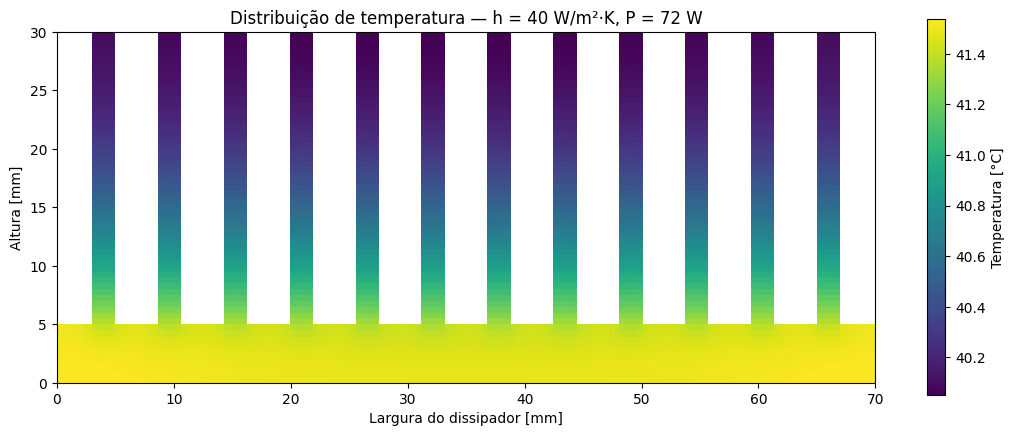

In [ ]:
# =========================
# CAMPO DE TEMPERATURA
# =========================
Path("figuras").mkdir(exist_ok=True)

def plot_field(res, h_val, path=None):
    fig, ax = plt.subplots(figsize=(11, 5))
    m = ax.pcolormesh(res["xe"]*1e3, res["ye"]*1e3, np.ma.masked_invalid(res["T"]),
                      cmap="viridis", shading="flat")
    ax.set_aspect("equal")
    ax.set_xlabel("Largura do dissipador [mm]")
    ax.set_ylabel("Altura [mm]")
    ax.set_title(f"Distribuição de temperatura — h = {h_val:g} W/m²·K, P = {P:g} W")
    fig.colorbar(m, ax=ax, label="Temperatura [°C]", shrink=0.8)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=200)
    plt.show()

plot_field(result_nominal, 40.0, "figuras/mapa_temperatura_h40.png")

## 5. Estudo de sensibilidade ao coeficiente convectivo

O relatório do projeto avalia:

`h = 5, 8, 10, 15, 20, 30 e 40 W/m²·K`.

O objetivo é verificar numericamente quando o dissipador ultrapassa ou permanece abaixo do limite de projeto de **80 °C**.

A classificação é feita exclusivamente pelo critério térmico:

- **Atende:** `Tmax ≤ 80 °C`;
- **Não atende:** `Tmax > 80 °C`.

Os resultados deste notebook são a **versão de referência** do gêmeo digital CAD–térmico e substituem os valores do modelo simplificado anterior, cujo código não faz parte dos arquivos do projeto e, portanto, não pôde ser auditado (ver seção 7).

In [ ]:
h_values = [5, 8, 10, 15, 20, 30, 40]
results = []

for h in h_values:
    r = solve_steady_state(h_conv=h)
    Tmax = np.nanmax(r["T"])
    Tmin = np.nanmin(r["T"])
    results.append({
        "h_W_m2K": h,
        "Tmax_C": Tmax,
        "Tmin_C": Tmin,
        "margin_C": T_lim_C - Tmax,
        "status": "Atende" if Tmax <= T_lim_C else "Não atende",
        "n_celulas": r["n_cells"],
        "erro_balanco_pct": 100.0*abs(r["P_conv"] - P)/P,
    })

print(" h [W/m²K] | Tmin [°C] | Tmax [°C] | Margem [°C] | Critério")
print("-"*67)
for r in results:
    print(f"{r['h_W_m2K']:10.0f} | {r['Tmin_C']:10.2f} | {r['Tmax_C']:10.2f} | "
          f"{r['margin_C']:11.2f} | {r['status']}")

 h [W/m²K] | Tmin [°C] | Tmax [°C] | Margem [°C] | Critério
-------------------------------------------------------------------
         5 |     149.03 |     150.55 |      -70.55 | Não atende
         8 |     102.32 |     103.83 |      -23.83 | Não atende
        10 |      86.75 |      88.26 |       -8.26 | Não atende
        15 |      65.99 |      67.50 |       12.50 | Atende
        20 |      55.61 |      57.12 |       22.88 | Atende
        30 |      45.24 |      46.73 |       33.27 | Atende
        40 |      40.05 |      41.54 |       38.46 | Atende


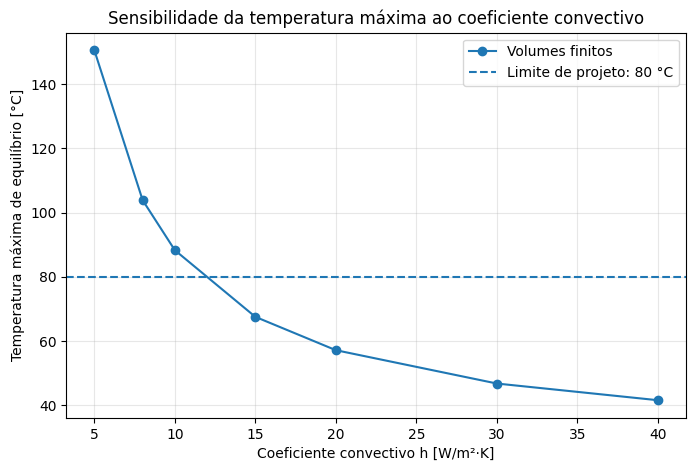

In [ ]:
# Curva de sensibilidade
hs = np.array([r["h_W_m2K"] for r in results])
Tmaxs = np.array([r["Tmax_C"] for r in results])

plt.figure(figsize=(8, 5))
plt.plot(hs, Tmaxs, "o-", label="Volumes finitos")
plt.axhline(T_lim_C, linestyle="--", label="Limite de projeto: 80 °C")
plt.xlabel("Coeficiente convectivo h [W/m²·K]")
plt.ylabel("Temperatura máxima de equilíbrio [°C]")
plt.title("Sensibilidade da temperatura máxima ao coeficiente convectivo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("figuras/sensibilidade_conveccao.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Verificação numérica: balanço de energia e independência de malha

Em equilíbrio térmico, a potência recebida pelo sólido deve ser igual à potência removida por convecção:

$$
P_{conv} = \int_A h(T-T_\infty)\,dA
$$

No esquema conservativo esta igualdade é satisfeita até o erro de arredondamento. Além disso, verifica-se que o resultado não depende da malha, comparando três níveis de refinamento (1×, 2× e 3×) no caso nominal.

In [ ]:
Pconv_nominal = result_nominal["P_conv"]
balance_error = 100.0 * abs(Pconv_nominal - P) / P

print(f"Potência gerada:      {P:.3f} W")
print(f"Potência convectiva:  {Pconv_nominal:.3f} W")
print(f"Erro de balanço:      {balance_error:.2e} %")
print(f"Maior erro de balanço entre os 7 casos: {max(r['erro_balanco_pct'] for r in results):.2e} %")

print("\nIndependência de malha (h = 40 W/m²·K):")
print(" refino | células | Tmax [°C] | Tmin [°C]")
mesh_study = []
for ref in (1, 2, 3):
    r = solve_steady_state(40.0, refine=ref)
    mesh_study.append((ref, r["n_cells"], np.nanmax(r["T"]), np.nanmin(r["T"])))
for ref, nc, tmx, tmn in mesh_study:
    print(f" {ref:6g} | {nc:7d} | {tmx:9.3f} | {tmn:9.3f}")
dT_mesh = abs(mesh_study[-1][2] - mesh_study[0][2])
print(f"Variação de Tmax entre malha base e malha 3×: {dT_mesh:.3f} °C")

Potência gerada:      72.000 W
Potência convectiva:  72.000 W
Erro de balanço:      1.10e-10 %
Maior erro de balanço entre os 7 casos: 6.16e-10 %

Independência de malha (h = 40 W/m²·K):
 refino | células | Tmax [°C] | Tmin [°C]


      1 |    3840 |    41.536 |    40.050
      2 |   15360 |    41.531 |    40.049
      3 |   34560 |    41.530 |    40.049
Variação de Tmax entre malha base e malha 3×: 0.006 °C


## 7. Temperatura de equilíbrio e comparação com o relatório anterior

O relatório anterior apresentava, para o modelo térmico simplificado, os valores de `Tmax` listados abaixo. A simulação atual é explicitamente ligada à geometria das 12 aletas e às condições de contorno do CAD, tem balanço de energia fechado e independência de malha verificada; portanto, é tratada como a **versão de referência do gêmeo digital CAD–térmico**.

A diferença é pequena na condição nominal (`h = 40`) e cresce para convecção fraca (`h` baixo), onde a temperatura é muito sensível à área efetiva de troca de calor. O código do modelo anterior não está disponível; por isso a causa exata da diferença não pôde ser auditada. A **classificação (atende/não atende) não muda** em nenhum dos sete casos.

In [ ]:
# Comparação explícita com os valores publicados no relatório anterior.
report_previous = {5: 140.7, 8: 98.3, 10: 84.2, 15: 65.3, 20: 55.9, 30: 46.5, 40: 41.7}
status_previous = {h: ("Atende" if t <= T_lim_C else "Não atende") for h, t in report_previous.items()}

current = {r["h_W_m2K"]: r["Tmax_C"] for r in results}

print("h [W/m²K] | Anterior [°C] | Atual (VF) [°C] | Diferença [°C] | Mesma classificação")
print("-"*80)

for h in h_values:
    diff = current[h] - report_previous[h]
    same = status_previous[h] == ("Atende" if current[h] <= T_lim_C else "Não atende")
    print(f"{h:9.0f} | {report_previous[h]:13.1f} | {current[h]:15.2f} | {diff:14.2f} | {'sim' if same else 'NÃO'}")

h [W/m²K] | Anterior [°C] | Atual (VF) [°C] | Diferença [°C] | Mesma classificação
--------------------------------------------------------------------------------
        5 |         140.7 |          150.55 |           9.85 | sim
        8 |          98.3 |          103.83 |           5.53 | sim
       10 |          84.2 |           88.26 |           4.06 | sim
       15 |          65.3 |           67.50 |           2.20 | sim
       20 |          55.9 |           57.12 |           1.22 | sim
       30 |          46.5 |           46.73 |           0.23 | sim
       40 |          41.7 |           41.54 |          -0.16 | sim


## 8. Critério de aceitação

Para o projeto, a condição nominal de ventilação forçada é considerada termicamente adequada quando:

$$
T_{max} \leq 80\ ^\circ C
$$

Além da temperatura, o projeto deve considerar a continuidade do fluxo de ar. Uma falha de ventilação reduz `h` e pode elevar rapidamente a temperatura.

O notebook permite alterar:

- potência da GPU;
- temperatura ambiente;
- número e espessura das aletas;
- dimensões da base e margem lateral;
- condutividade do material;
- coeficiente convectivo;
- resolução da malha (`refine`) e largura da fonte de calor (`w_src`).

Isso permite utilizar o mesmo código como núcleo computacional do gêmeo digital.

In [ ]:
# =========================
# CENÁRIO NOMINAL FINAL
# =========================
nominal = next(r for r in results if r["h_W_m2K"] == 40)
R_theta = (nominal["Tmax_C"] - T_amb_C) / P

print("=== VERIFICAÇÃO FINAL ===")
print(f"Potência:              {P:.1f} W")
print(f"Ambiente:              {T_amb_C:.1f} °C")
print(f"h nominal:             40 W/m²·K")
print(f"Tmax de equilíbrio:    {nominal['Tmax_C']:.2f} °C")
print(f"Tmin de equilíbrio:    {nominal['Tmin_C']:.2f} °C")
print(f"Limite de projeto:     {T_lim_C:.1f} °C")
print(f"Margem térmica:        {nominal['margin_C']:.2f} °C")
print(f"Rθ aparente:           {R_theta:.3f} °C/W")
print(f"Critério:              {nominal['status']}")
print(f"Erro de balanço:       {nominal['erro_balanco_pct']:.2e} %")

# Dilatação e tensão térmica (seção 8 do relatório): ΔT = Tmax - T_amb
alpha, E = 23e-6, 70e9
print("\nDilatação livre em 170 mm e tensão totalmente restringida (limite superior):")
for h in (40, 10):
    dT = current[h] - T_amb_C
    print(f"h = {h:2d}: ΔT = {dT:5.1f} °C | ΔL = {alpha*L*dT*1e3:.3f} mm | σ = {E*alpha*dT/1e6:5.1f} MPa")

=== VERIFICAÇÃO FINAL ===
Potência:              72.0 W
Ambiente:              25.0 °C
h nominal:             40 W/m²·K
Tmax de equilíbrio:    41.54 °C
Tmin de equilíbrio:    40.05 °C
Limite de projeto:     80.0 °C
Margem térmica:        38.46 °C
Rθ aparente:           0.230 °C/W
Critério:              Atende
Erro de balanço:       1.10e-10 %

Dilatação livre em 170 mm e tensão totalmente restringida (limite superior):
h = 40: ΔT =  16.5 °C | ΔL = 0.065 mm | σ =  26.6 MPa
h = 10: ΔT =  63.3 °C | ΔL = 0.247 mm | σ = 101.9 MPa


### Teste opcional de sensibilidade à fonte de calor

O modelo base distribui o calor uniformemente em toda a largura da base. O teste abaixo concentra os 72 W em uma faixa central de 50 mm (largura da camada de TIM do CAD integrado, que é uma hipótese geométrica) para quantificar o efeito da concentração do calor sobre `Tmax`.

In [ ]:
print("Fonte concentrada (faixa central) — h = 40 W/m²·K")
for ws in (W, 50e-3, 30e-3):
    r = solve_steady_state(40.0, w_src=ws)
    print(f"largura da fonte = {ws*1e3:4.0f} mm -> Tmax = {np.nanmax(r['T']):.2f} °C")

Fonte concentrada (faixa central) — h = 40 W/m²·K
largura da fonte =   70 mm -> Tmax = 41.54 °C
largura da fonte =   50 mm -> Tmax = 42.01 °C
largura da fonte =   30 mm -> Tmax = 42.75 °C


## 9. Conclusão da simulação

A solução por volumes finitos resolve a equação do calor no domínio sólido do dissipador e aplica uma condição convectiva nas superfícies expostas, com balanço de energia fechado.

O valor de `Tmax` após a solução representa a **temperatura de equilíbrio** para o cenário analisado.

### Integração com o CAD

A correspondência dos principais parâmetros é:

| Parâmetro | CAD / relatório | Notebook |
|---|---|---|
| Base | 170 × 70 × 5 mm | `L`, `W`, `t_base` |
| Aletas | 12 unidades | `N_fin` |
| Espessura | 2 mm | `t_fin` |
| Altura | 25 mm | `h_fin` |
| Margem lateral | 3 mm | `margem` |
| Material | Al 6061 | `k_al` |
| Potência | 72 W | `P` |
| Ambiente | 25 °C | `T_amb_C` |
| Convecção | 5–40 W/m²·K | `h_values` |
| Limite | 80 °C | `T_lim_C` |

**Regra de rastreabilidade:** se uma dimensão do CAD for alterada, o parâmetro correspondente do notebook deve ser alterado antes de considerar os resultados como pertencentes à mesma versão do gêmeo digital.